In [11]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
from utils.data_loader import ImagenetteDataLoader
from model import Network

import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(96, 96)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 96, 96))

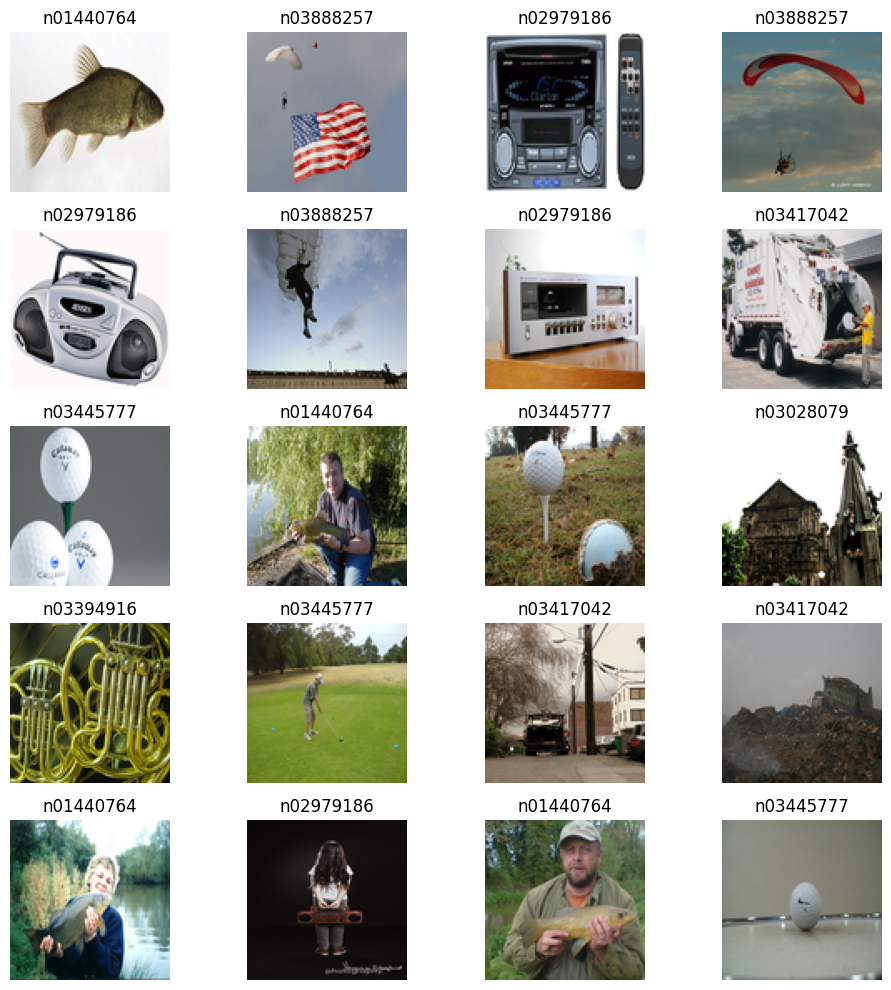

In [3]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [4]:
layer_definitions = [
    {"type": "Conv", "num_filters": 16, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Conv", "num_filters": 32, "num_channels": 16, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Conv", "num_filters": 64, "num_channels": 32, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Conv", "num_filters": 64, "num_channels": 64, "kernel_height": 3, "kernel_width": 3, "padding": 0, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "Flatten"},
    {"type": "ReLU", "input_size": 1024, "num_neurons": 256},
    {"type": "ReLU", "input_size": 256, "num_neurons": 64},
    {"type": "Softmax", "input_size": 64, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [5]:
network.describe()

Network Architecture

Layer 1: ConvLayer
  Filters Shape: (16, 3, 3, 3) | Biases Shape: (16,)
  Parameters: 448

Layer 2: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 3: ConvLayer
  Filters Shape: (32, 16, 3, 3) | Biases Shape: (32,)
  Parameters: 4,640

Layer 4: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 5: ConvLayer
  Filters Shape: (64, 32, 3, 3) | Biases Shape: (64,)
  Parameters: 18,496

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: ConvLayer
  Filters Shape: (64, 64, 3, 3) | Biases Shape: (64,)
  Parameters: 36,928

Layer 8: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 9: FlattenLayer
  Parameters: 0

Layer 10: ReluLayer
  Weights Shape: (1024, 256) | Biases Shape: (256,)
  Parameters: 262,400

Layer 11: ReluLayer
  Weights Shape: (256, 64) | Biases Shape: (64,)
  Parameters: 16,448

Layer 12: SoftmaxLayer
  Weights Shape: (64, 10) | Biases Shape: (10,)
  Parameters: 650

Total Parameters: 340,010


In [6]:
batch_size = 16
epochs = 10

base_learning_rate = 0.003
min_learning_rate = 0.0001
train_num_batches = (len(train_loader) + batch_size - 1) // batch_size
total_steps = epochs * train_num_batches

global_step = 0

for epoch in range(epochs):
    total_loss = 0.0

    for batch_idx, (x_batch, y_batch) in enumerate(
        train_loader.iter_batches(batch_size=batch_size, normalize=True, one_hot=True, shuffle=True),
        start=1
    ):
        learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

        outputs = network.forward(input=x_batch)
        y_pred = outputs[-1]

        error = y_pred - y_batch
        loss = network.cce_loss(y_pred=y_pred, y_true=y_batch).item()
        total_loss += loss

        network.backward(output_error=error, batch_size=x_batch.shape[0])
        network.update_parameters(learning_rate=learning_rate)

        global_step += 1

    print(f"Epoch {epoch + 1}/{epochs} completed. Avg Loss: {total_loss / train_num_batches:.6f}")

Epoch 1/10 completed. Avg Loss: 2.015559
Epoch 2/10 completed. Avg Loss: 1.661461
Epoch 3/10 completed. Avg Loss: 1.473276
Epoch 4/10 completed. Avg Loss: 1.336829
Epoch 5/10 completed. Avg Loss: 1.233012
Epoch 6/10 completed. Avg Loss: 1.134575
Epoch 7/10 completed. Avg Loss: 1.063222
Epoch 8/10 completed. Avg Loss: 1.006738
Epoch 9/10 completed. Avg Loss: 0.965503
Epoch 10/10 completed. Avg Loss: 0.946319


In [9]:
correct_predictions = 0
num_train_samples = 0
train_num_batches = (len(train_loader) + batch_size - 1) // batch_size

print(f"Evaluating on training set with {train_num_batches} batches")

for x_batch, y_batch in train_loader.iter_batches(
    batch_size=batch_size,
    normalize=True,
    one_hot=True,
    shuffle=False
):
    outputs = network.forward(input=x_batch)
    y_pred = outputs[-1]

    predicted_labels = cp.argmax(y_pred, axis=1)
    true_labels = cp.argmax(y_batch, axis=1)

    correct_predictions += cp.sum(predicted_labels == true_labels).item()
    num_train_samples += x_batch.shape[0]

accuracy = correct_predictions / num_train_samples
print(f"Train Accuracy: {accuracy:.4f}")

Evaluating on training set with 592 batches
Train Accuracy: 0.7012


In [7]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(96, 96)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 96, 96))

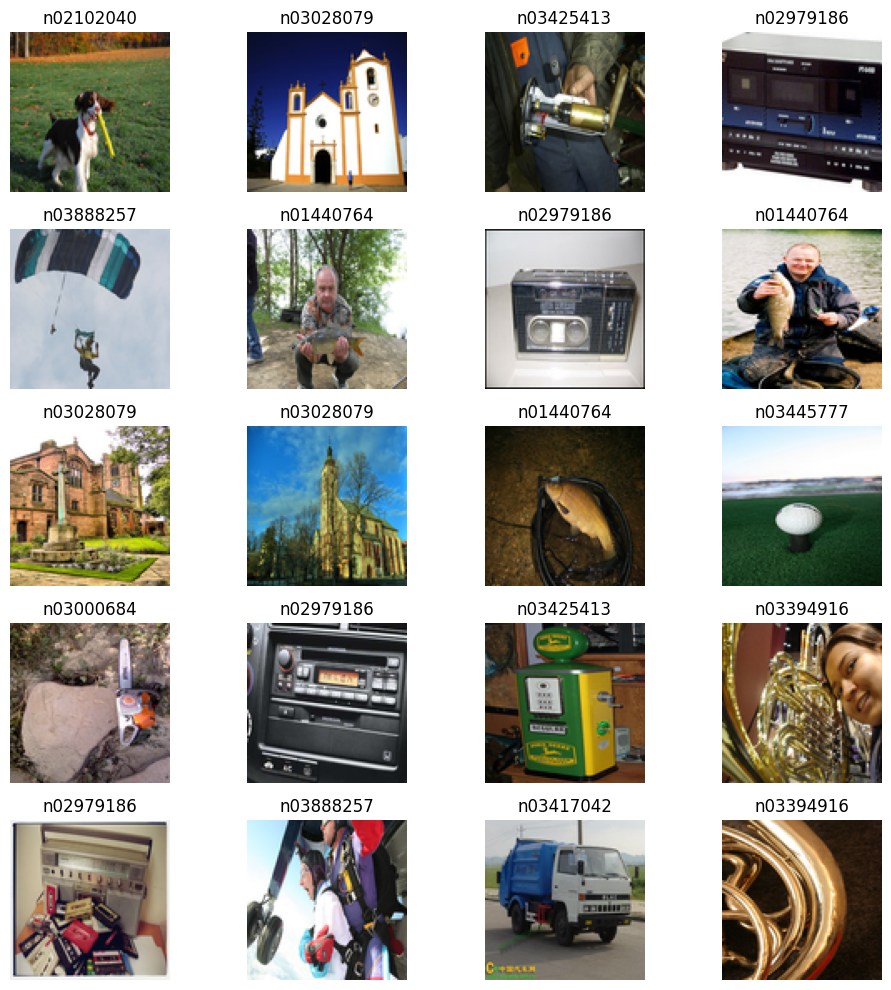

In [8]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(random_indices.get().tolist(), figsize=(10, 10))

In [10]:
correct_predictions = 0
num_test_samples = 0
test_num_batches = (len(test_loader) + batch_size - 1) // batch_size

print(f"Evaluating on test set with {test_num_batches} batches")

for x_batch, y_batch in test_loader.iter_batches(
    batch_size=batch_size,
    normalize=True,
    one_hot=True,
    shuffle=False
):
    outputs = network.forward(input=x_batch)
    y_pred = outputs[-1]

    predicted_labels = cp.argmax(y_pred, axis=1)
    true_labels = cp.argmax(y_batch, axis=1)

    correct_predictions += cp.sum(predicted_labels == true_labels).item()
    num_test_samples += x_batch.shape[0]

accuracy = correct_predictions / num_test_samples
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating on test set with 246 batches
Test Accuracy: 0.5944
